In [115]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# 词典的大小，LLama 3的词典实际词典大小为128256，这里只是为了演示
v = 100

# Llama的最大seq_len是8192， 在这里设置为8
seq_len = 8

# batch size
b = 1

# 随机生成token序列作为演示
tokens = torch.randint(v, (b, seq_len))
tokens.shape, tokens

# embedding dimension
d = 32 

num_heads = 4 # Llama 3 8b 拥有32个attention heads.
head_dim = d // num_heads 

https://medium.com/@ccibeekeoc42/unlocking-low-resource-language-understanding-enhancing-translation-with-llama-3-fine-tuning-df8f1d04d206 (图片来自于这里）
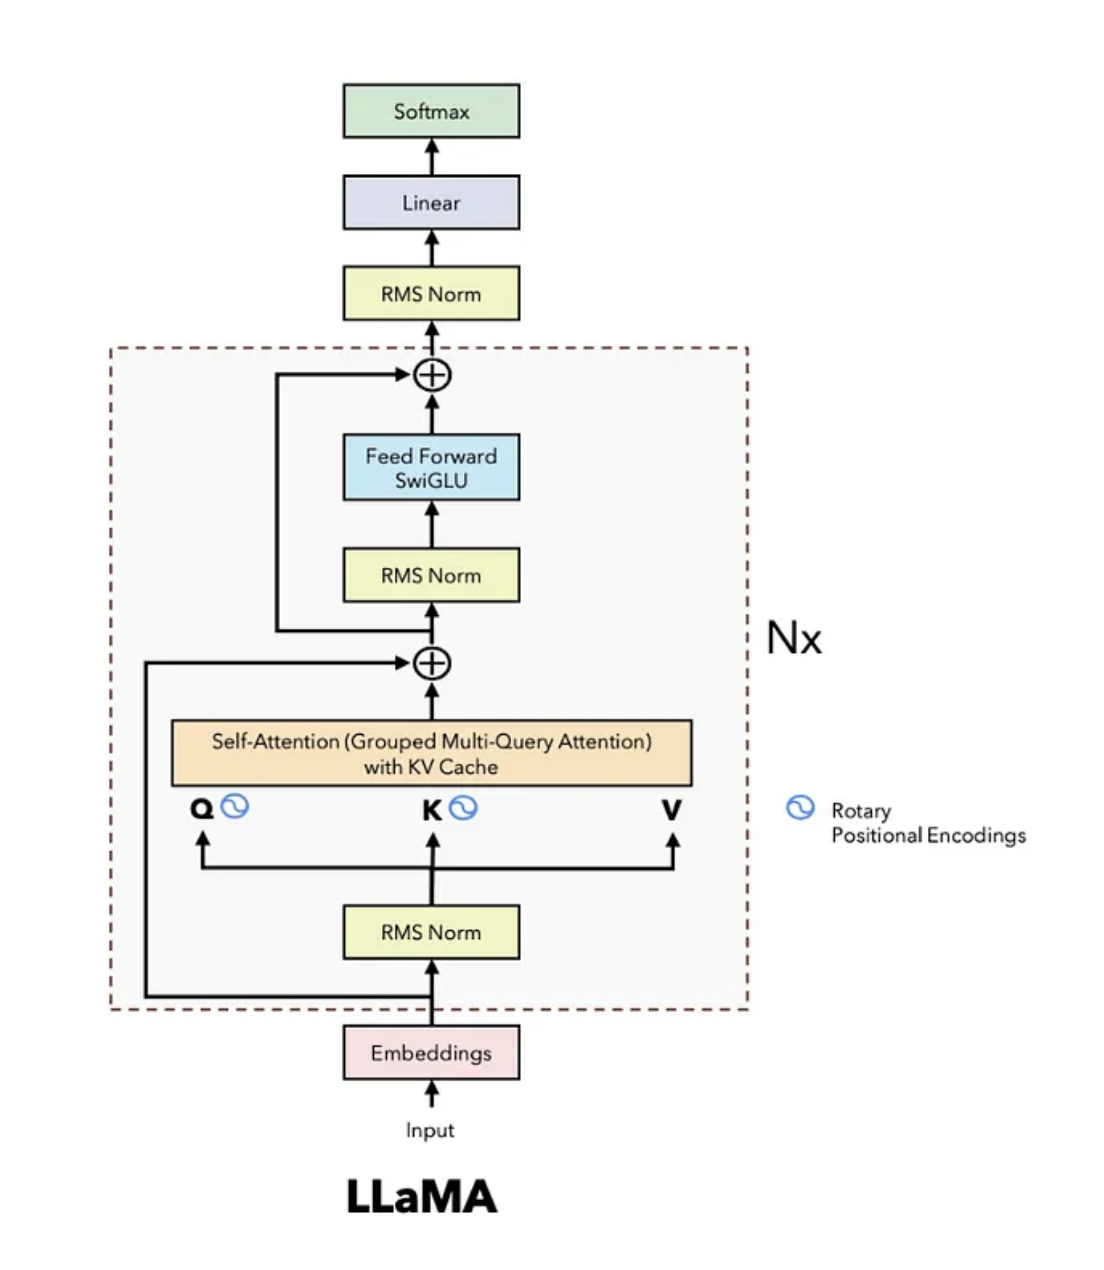

### 1. 创建Embedding矩阵，并对于输入获取 token embeddings

In [116]:
tokens

tensor([[54, 92, 51, 60, 94, 78, 98, 86]])

In [117]:
# embedding 矩阵，大小为 V*d
embedding = nn.Embedding(v, d)
embedding.weight.shape, embedding.weight

(torch.Size([100, 32]),
 Parameter containing:
 tensor([[ 1.2253,  0.7600, -1.0412,  ..., -0.6432, -0.3377,  0.8834],
         [ 1.1533, -0.0647,  0.7313,  ..., -1.5883,  0.3775,  0.8133],
         [-0.5414, -0.7053,  0.1246,  ..., -1.4146,  0.6800,  0.4629],
         ...,
         [ 0.1876, -0.4117,  1.5918,  ..., -0.3259, -0.2618,  0.8409],
         [-1.1185, -0.6660, -0.6005,  ..., -0.3109,  0.1772, -0.2095],
         [ 0.3554,  0.9844, -1.4502,  ..., -0.6525, -0.8257,  0.2049]],
        requires_grad=True))

In [118]:
# 对于token获取对应的embedding向量
x = embedding(tokens)
x.shape, x

(torch.Size([1, 8, 32]),
 tensor([[[ 0.5562, -0.1346, -0.1817,  2.1108, -0.2764,  1.1942,  0.1739,
           -0.0630, -0.4651,  0.3281,  0.2182, -0.4241,  1.4360,  0.5941,
           -0.5733,  1.3207,  0.6880, -1.6096, -0.9762, -0.2055,  1.0600,
            0.4638,  0.0345,  1.5586,  0.6188, -0.4648,  0.5069,  0.3695,
           -0.7012, -0.3651, -1.5491, -0.8554],
          [-0.9678,  0.8365, -0.3471,  0.5360, -0.2428, -1.0509, -0.6471,
            0.5183, -0.5768, -1.2018, -0.1418,  1.2525, -1.6380, -0.1010,
           -0.2100, -1.0186, -0.5272, -0.0942,  0.6116, -0.5859, -2.0355,
           -0.4043, -0.0392,  0.1957,  1.1996, -0.3485,  1.3943,  0.2060,
            1.8912, -0.2544, -0.7499,  0.2479],
          [-1.0342, -1.4441, -0.3858, -0.2255, -1.1036, -1.0686, -0.9107,
           -0.4193, -0.1736,  1.6574,  0.9193,  0.0858,  0.0589,  0.0999,
           -1.1754, -1.0985,  0.2541, -1.4229, -0.9744, -1.2280, -2.4404,
           -1.5729,  0.7208,  0.4012,  0.0540,  0.5557, -0.8092, 

### 2. 创建masked matrix, 后续在self-attention中会用到

In [119]:
# masked matrix
mask = torch.full(
    (seq_len, seq_len),
    float("-inf")
)
mask = torch.triu(mask, diagonal=1)
mask

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

In [120]:
# residual connection
h=x # h是不动的

In [121]:
x.shape

torch.Size([1, 8, 32])

### 3. (a) RMS Normalization 

In [122]:
mean_squared = x.pow(2).mean(dim=-1, keepdim=True)

In [123]:
mean_squared

tensor([[[0.7490],
         [0.7562],
         [0.9349],
         [1.4124],
         [1.0339],
         [0.8914],
         [0.6240],
         [0.8638]]], grad_fn=<MeanBackward1>)

In [124]:
x_normed = x * torch.rsqrt(mean_squared + 1e-6)

In [125]:
print (f'x_normed: {x_normed.shape}\n{x_normed}')

x_normed: torch.Size([1, 8, 32])
tensor([[[ 0.6427, -0.1555, -0.2099,  2.4389, -0.3193,  1.3799,  0.2010,
          -0.0728, -0.5374,  0.3792,  0.2521, -0.4900,  1.6592,  0.6864,
          -0.6624,  1.5260,  0.7949, -1.8598, -1.1280, -0.2375,  1.2247,
           0.5358,  0.0399,  1.8009,  0.7150, -0.5370,  0.5857,  0.4269,
          -0.8102, -0.4218, -1.7899, -0.9884],
         [-1.1129,  0.9619, -0.3991,  0.6164, -0.2793, -1.2085, -0.7442,
           0.5960, -0.6633, -1.3820, -0.1630,  1.4403, -1.8836, -0.1161,
          -0.2415, -1.1713, -0.6063, -0.1083,  0.7033, -0.6738, -2.3408,
          -0.4649, -0.0451,  0.2250,  1.3794, -0.4008,  1.6034,  0.2369,
           2.1748, -0.2926, -0.8623,  0.2851],
         [-1.0695, -1.4935, -0.3990, -0.2332, -1.1414, -1.1052, -0.9419,
          -0.4336, -0.1796,  1.7141,  0.9507,  0.0888,  0.0610,  0.1033,
          -1.2156, -1.1360,  0.2628, -1.4716, -1.0077, -1.2700, -2.5239,
          -1.6267,  0.7455,  0.4149,  0.0558,  0.5747, -0.8369, -0.045

In [126]:
rms_scale = torch.ones(d)

In [127]:
x_normed *= rms_scale

In [128]:
x_normed.shape

torch.Size([1, 8, 32])

In [129]:
# 以函数的方式来实现RMSNorm
class RMSNorm(torch.nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def _norm(self,x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True))+self.eps
        
    def forward(self,x):
        output = self._norm(x.float()).type_as(x)
        return output * self.weight

### 3.(b) Layer Normalization

In [130]:
class LayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super(LayerNorm, self).__init__()
        self.eps = eps
        # Create two learnable parameters for normalization
        self.gamma = nn.Parameter(torch.ones(normalized_shape))
        self.beta = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x):
        # Calculate the mean and standard deviation
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True, unbiased=False)

        # Normalize the batch of tensors
        x_normalized = (x - mean) / (std + self.eps)

        # Scale and shift
        return self.gamma * x_normalized + self.beta
    
test_input = torch.randn(3, 5)
layer_norm = nn.LayerNorm(test_input.size(-1))

# Apply LayerNorm to the input tensor
normalized_tensor = layer_norm(test_input)

test_input,normalized_tensor

(tensor([[-2.7886,  1.2365, -0.1004,  0.5096, -0.5599],
         [ 0.5729,  3.5225,  1.1559,  0.8271, -0.3845],
         [ 0.3213,  0.1304, -0.5061, -0.2097,  0.3588]]),
 tensor([[-1.7942,  1.1558,  0.1760,  0.6231, -0.1608],
         [-0.4361,  1.8369,  0.0132, -0.2402, -1.1738],
         [ 0.9139,  0.3369, -1.5869, -0.6911,  1.0271]],
        grad_fn=<NativeLayerNormBackward0>))

### 4. Multi-head Attention (Grouped Query Attention)

In [131]:
# num_heads = 4  
num_kv_heads = 2 
assert num_heads % num_kv_heads == 0
print (f"num_heads = {num_heads}, head_dim = {head_dim}")

num_heads = 4, head_dim = 8


In [132]:
wq = nn.Linear(d, num_heads * head_dim, bias=False)
wk = nn.Linear(d, num_kv_heads * head_dim, bias=False)
wv = nn.Linear(d, num_kv_heads * head_dim, bias=False)
print ("attention weights: ", wq.weight.shape, wk.weight.shape, wv.weight.shape)


attention weights:  torch.Size([32, 32]) torch.Size([16, 32]) torch.Size([16, 32])


In [146]:
xq = wq(x_normed)
xk = wk(x_normed)
xv = wv(x_normed)
print("Attention projections: ", xq.shape, xk.shape, xv.shape)

Attention projections:  torch.Size([1, 8, 32]) torch.Size([1, 8, 16]) torch.Size([1, 8, 16])


In [147]:
xq.shape, xk.shape, xv.shape

(torch.Size([1, 8, 32]), torch.Size([1, 8, 16]), torch.Size([1, 8, 16]))

In [134]:
xq = xq.view(b, seq_len, num_heads, head_dim)
xk = xk.view(b, seq_len, num_kv_heads, head_dim)
xv = xv.view(b, seq_len, num_kv_heads, head_dim)

RuntimeError: shape '[1, 8, 2, 8]' is invalid for input of size 256

In [135]:
xq.shape, xk.shape, xv.shape

(torch.Size([1, 8, 4, 8]), torch.Size([1, 8, 4, 8]), torch.Size([1, 8, 4, 8]))

In [136]:
if num_kv_heads != num_heads:
    num_queries_per_kv = num_heads // num_kv_heads
    xk = torch.repeat_interleave(xk, num_queries_per_kv, dim=2)
    xv = torch.repeat_interleave(xv, num_queries_per_kv, dim=2)

xq.shape, xk.shape, xv.shape

(torch.Size([1, 8, 4, 8]), torch.Size([1, 8, 8, 8]), torch.Size([1, 8, 8, 8]))

In [137]:
# Transposes Q, K, and V 矩阵
xq = xq.transpose(1, 2)
xk = xk.transpose(1, 2)
xv = xv.transpose(1, 2)

xq.shape, xk.shape, xv.shape

(torch.Size([1, 4, 8, 8]), torch.Size([1, 8, 8, 8]), torch.Size([1, 8, 8, 8]))

In [138]:
# attention矩阵的计算
scores = torch.matmul(xq, xk.transpose(2, 3))
scores = scores / math.sqrt(head_dim)

scores.shape, scores

RuntimeError: The size of tensor a (4) must match the size of tensor b (8) at non-singleton dimension 1

In [139]:
# 不能让token看到未来的token
scores = scores + mask

scores.shape, scores

RuntimeError: The size of tensor a (4) must match the size of tensor b (8) at non-singleton dimension 3

In [140]:
# 进行softmax计算，输出概率
scores = F.softmax(scores.float(), dim=-1).type_as(xq)

In [141]:
# 之后乘以 Value矩阵 
output = torch.matmul(scores, xv)
output.shape, output

RuntimeError: Expected size for first two dimensions of batch2 tensor to be: [8, 4] but got: [8, 8].

In [142]:
output = output.transpose(1, 2).contiguous().view(b, seq_len, -1)
output.shape, output

(torch.Size([1, 8, 32]),
 tensor([[[-6.7626e-01, -5.7522e-01, -4.7518e-01, -3.7846e-01,  5.1674e-02,
           -1.4277e-01, -1.0978e-01, -5.5545e-02, -5.0429e-01,  7.3224e-02,
           -1.6134e-01, -8.9987e-02,  2.1115e-01, -4.8833e-02, -7.9875e-02,
            1.3743e-02,  6.6226e-01,  5.7290e-01,  7.1429e-01,  7.0203e-01,
            8.7498e-01,  8.3454e-01,  5.8259e-01,  6.5277e-01, -7.0015e-01,
           -1.8366e-01, -6.2242e-01, -6.8091e-01, -5.5638e-01, -6.6586e-01,
           -2.4612e-01, -4.1447e-01],
          [-3.5534e-01, -6.8973e-01, -5.7506e-01, -5.7710e-01, -4.2370e-01,
           -4.4209e-01, -2.9392e-01, -4.7875e-01, -3.5495e-01, -1.0834e-01,
           -2.9190e-01, -2.4146e-01, -4.3518e-01, -4.5447e-01, -2.3404e-01,
           -3.4156e-01, -5.4498e-03, -1.4924e-01, -7.2348e-02,  8.9775e-02,
            2.5005e-01,  1.7525e-01,  8.8081e-02,  1.0888e-01, -8.5147e-03,
           -1.6642e-01, -2.6517e-01, -6.0121e-02, -2.8623e-01, -3.2271e-01,
           -2.3739e-01, -

In [143]:
# output projection 
wo = nn.Linear(num_heads * head_dim, d, bias=False)
Xout = wo(output)
Xout.shape, Xout

(torch.Size([1, 8, 32]),
 tensor([[[-0.5927, -0.1399,  0.3700,  0.0342, -0.0991, -0.2761, -0.0845,
            0.2308, -0.0635,  0.0621, -0.1343,  0.1079, -0.1136, -0.4319,
           -0.1227,  0.1268, -0.4843,  0.2412,  0.0290,  0.1519, -0.2354,
            0.4055,  0.1447,  0.0874, -0.0646,  0.1406, -0.4808,  0.3671,
           -0.1439, -0.1713,  0.1883,  0.2210],
          [-0.2154, -0.0672,  0.0420,  0.2641,  0.0795,  0.0872, -0.0909,
            0.0453,  0.1128,  0.0569, -0.2027, -0.0326,  0.1175,  0.0880,
            0.0542,  0.3117, -0.2401, -0.1479, -0.1283,  0.0221, -0.2731,
            0.0441,  0.0133,  0.1479,  0.3981,  0.1745, -0.0739,  0.2016,
           -0.1650,  0.3076, -0.1212,  0.2628],
          [-0.5956, -0.0512,  0.2933,  0.0371,  0.0028, -0.2894, -0.1500,
            0.2086, -0.0551,  0.0988, -0.1767,  0.0425, -0.1625, -0.4246,
           -0.0853,  0.0736, -0.5115,  0.2102, -0.0360,  0.2337, -0.2495,
            0.3771,  0.2136,  0.1201, -0.0353,  0.0997, -0.4329, 

In [144]:
h += Xout
h.shape, h

(torch.Size([1, 8, 32]),
 tensor([[[-3.6474e-02, -2.7447e-01,  1.8830e-01,  2.1450e+00, -3.7543e-01,
            9.1812e-01,  8.9408e-02,  1.6781e-01, -5.2863e-01,  3.9027e-01,
            8.3939e-02, -3.1612e-01,  1.3224e+00,  1.6219e-01, -6.9598e-01,
            1.4475e+00,  2.0372e-01, -1.3683e+00, -9.4727e-01, -5.3634e-02,
            8.2460e-01,  8.6925e-01,  1.7929e-01,  1.6460e+00,  5.5425e-01,
           -3.2414e-01,  2.6056e-02,  7.3659e-01, -8.4506e-01, -5.3632e-01,
           -1.3608e+00, -6.3442e-01],
          [-1.1831e+00,  7.6930e-01, -3.0513e-01,  8.0014e-01, -1.6335e-01,
           -9.6368e-01, -7.3798e-01,  5.6357e-01, -4.6398e-01, -1.1449e+00,
           -3.4452e-01,  1.2199e+00, -1.5205e+00, -1.3013e-02, -1.5578e-01,
           -7.0686e-01, -7.6727e-01, -2.4207e-01,  4.8323e-01, -5.6385e-01,
           -2.3087e+00, -3.6018e-01, -2.5951e-02,  3.4357e-01,  1.5976e+00,
           -1.7406e-01,  1.3204e+00,  4.0762e-01,  1.7262e+00,  5.3236e-02,
           -8.7106e-01,  

In [145]:
# RMS normalization
rmsNorm = RMSNorm(d)
h_normed = rmsNorm(h)

### 5. SwiGLU Feedforward Network

In [75]:
h_normed

tensor([[[-1.8259e+00,  2.2006e-01, -4.3284e-01, -1.7331e+00,  6.7400e-01,
           3.7464e-01, -3.4688e-02, -2.6829e-01,  8.7968e-02,  3.5712e-01,
           1.4952e-01,  2.0316e-01,  1.1039e+00,  9.7050e-01, -3.7064e-01,
          -9.7870e-01, -1.5167e+00, -8.0971e-01, -2.2396e+00, -4.0800e-01,
          -1.1034e+00,  1.3566e+00, -2.6300e+00,  3.0393e-02,  1.1301e+00,
           4.4541e-01, -3.3621e-01,  1.7818e-02,  1.3390e-02,  1.0773e+00,
          -3.2685e-01, -5.7802e-01],
         [-1.4927e+00, -8.8121e-02, -5.6113e-01,  7.0572e-01,  1.4625e+00,
          -8.1073e-01, -1.7483e+00,  2.8054e-01, -1.7777e+00, -2.8649e-01,
          -9.8822e-01, -2.7549e-01, -7.8610e-01, -5.6327e-01,  2.0772e+00,
          -8.7867e-01, -1.8819e+00, -6.7745e-02, -1.9828e+00, -7.9158e-01,
           2.9114e-01, -1.4785e-01,  3.9552e-01,  1.0827e+00, -1.2919e+00,
          -3.0700e-01,  2.4802e-01,  5.4343e-01,  2.0569e-01, -7.5625e-01,
           5.4082e-02, -6.5270e-01],
         [ 6.4527e-01,  2.

In [76]:
hidden_dim=256

In [77]:
up = nn.Linear(d, hidden_dim, bias=False)
gate = nn.Linear(d, hidden_dim, bias=False)
down = nn.Linear(hidden_dim, d, bias=False)

In [78]:
up_proj = up(h_normed)
print(up_proj.shape, up_proj)

torch.Size([1, 8, 256]) tensor([[[ 0.6139,  0.7843, -0.4310,  ..., -1.0993, -0.2864, -0.4071],
         [-0.6507, -0.4133, -0.3045,  ..., -0.0857, -0.2923,  0.2914],
         [ 0.4440,  0.2198,  1.3337,  ...,  0.3066, -0.3744,  1.2045],
         ...,
         [ 0.7600, -0.1326,  0.1308,  ...,  0.4738,  0.3328,  0.1955],
         [ 0.1960,  0.4186, -1.7017,  ...,  0.3636,  1.3872, -0.0623],
         [-0.0484, -0.2737, -0.8517,  ...,  0.4225,  0.0731,  0.4237]]],
       grad_fn=<UnsafeViewBackward0>)


In [79]:
gate_proj = F.silu(gate(h_normed))
print(gate_proj.shape, gate_proj)

torch.Size([1, 8, 256]) tensor([[[-0.1919,  0.1155, -0.2080,  ..., -0.0059,  0.2767, -0.1305],
         [-0.2208, -0.1107,  1.1960,  ..., -0.1270,  0.1010, -0.2429],
         [-0.2420,  0.2660, -0.2443,  ...,  0.0937,  0.3778, -0.0703],
         ...,
         [ 1.2163, -0.2779,  0.3440,  ...,  0.3273,  0.2262, -0.1969],
         [-0.1740, -0.0139, -0.0241,  ..., -0.2779, -0.1465,  0.7149],
         [ 0.5088,  0.1965,  0.0515,  ..., -0.0475, -0.1582, -0.2770]]],
       grad_fn=<SiluBackward0>)


In [80]:
ffwd_output = down(up_proj * gate_proj)
print(ffwd_output.shape, ffwd_output)

torch.Size([1, 8, 32]) tensor([[[-0.0016, -0.0658, -0.0696, -0.2247,  0.0597,  0.0015, -0.1979,
           0.0059, -0.0665, -0.0022, -0.0588, -0.0793, -0.0877, -0.1139,
           0.0328, -0.0196, -0.2623, -0.0714, -0.0169,  0.0871,  0.0014,
           0.1552, -0.1080, -0.0803,  0.0992, -0.0674, -0.0306, -0.1770,
           0.0300,  0.0266,  0.1086,  0.3289],
         [-0.0322,  0.0230, -0.0837,  0.0911,  0.0225, -0.0820, -0.0696,
          -0.0808,  0.0474,  0.0311, -0.0154,  0.0988,  0.0809,  0.0243,
           0.0059, -0.0501, -0.1091, -0.0706,  0.1101,  0.1610,  0.0780,
           0.0327,  0.0279, -0.1054,  0.0035, -0.0914,  0.0929, -0.1732,
           0.0280, -0.0480,  0.0345,  0.0850],
         [ 0.0453,  0.1104, -0.1798, -0.1143, -0.1277, -0.0076, -0.0986,
           0.0824,  0.1683,  0.0140, -0.0381, -0.0672, -0.0545,  0.0298,
          -0.1453,  0.0541,  0.1667,  0.1396,  0.1350, -0.0416,  0.1221,
           0.1324, -0.0414,  0.0508,  0.0236, -0.1354, -0.0858,  0.1153,
       

In [81]:
# residual layer
out = h + ffwd_output
print(out.shape, out)

torch.Size([1, 8, 32]) tensor([[[-2.2367e+00,  2.0354e-01, -5.9946e-01, -2.3463e+00,  8.8477e-01,
           4.6010e-01, -2.4041e-01, -3.2255e-01,  4.1217e-02,  4.3495e-01,
           1.2422e-01,  1.6936e-01,  1.2636e+00,  1.0741e+00, -4.2093e-01,
          -1.2177e+00, -2.1190e+00, -1.0627e+00, -2.7585e+00, -4.1238e-01,
          -1.3493e+00,  1.8158e+00, -3.3275e+00, -4.3136e-02,  1.4826e+00,
           4.7783e-01, -4.4217e-01, -1.5517e-01,  4.6377e-02,  1.3454e+00,
          -2.9156e-01, -3.7872e-01],
         [-1.6213e+00, -7.0841e-02, -6.8103e-01,  8.4241e-01,  1.5795e+00,
          -9.4507e-01, -1.9309e+00,  2.1783e-01, -1.8451e+00, -2.7389e-01,
          -1.0675e+00, -1.9453e-01, -7.5594e-01, -5.7540e-01,  2.2172e+00,
          -9.8551e-01, -2.1125e+00, -1.4268e-01, -2.0008e+00, -6.8170e-01,
           3.8796e-01, -1.2467e-01,  4.4895e-01,  1.0472e+00, -1.3718e+00,
          -4.1821e-01,  3.5699e-01,  4.0535e-01,  2.4697e-01, -8.5312e-01,
           9.2110e-02, -6.0984e-01],
   

In [82]:
final_norm = RMSNorm(d)
out_normed = final_norm(out)

### 6. final output layer

In [83]:
# then multiply by the linear layer to get our final output logits
final_output = nn.Linear(d, v, bias=False)
logits = final_output(out_normed).float()
logits.shape, logits

(torch.Size([1, 8, 100]),
 tensor([[[ 8.0471e-01,  1.2933e+00, -5.0535e-01,  8.1442e-01, -1.0117e-01,
           -2.5217e-01, -3.5754e-01,  8.1635e-01,  3.8645e-02, -1.7279e-01,
            2.4076e-01,  4.9291e-01, -3.2410e-01, -3.3036e-01,  9.9981e-01,
            6.2707e-01, -6.2566e-01,  1.1278e+00, -2.8199e-01,  4.8006e-01,
           -3.1152e-01,  5.8890e-01, -4.6707e-01, -8.1295e-01,  4.2618e-02,
            4.4982e-01, -1.0772e+00,  1.8860e-01,  3.2990e-01, -4.4731e-01,
           -9.7991e-02, -1.6806e-01,  6.3770e-01, -3.0885e-01,  1.0177e+00,
           -3.4499e-01, -6.9594e-01,  1.1153e+00, -2.7281e-01, -1.0377e-01,
           -4.6136e-01,  3.3891e-01,  2.5440e-01,  2.9232e-01, -3.1183e-01,
           -6.5745e-01,  7.8873e-01,  1.6348e-01,  4.3084e-01, -7.5898e-01,
            2.4871e-01,  6.1463e-01,  7.9430e-01, -9.9963e-01,  4.6019e-02,
            6.7557e-01, -8.1991e-01, -2.5950e-01,  3.9598e-01, -2.7357e-01,
           -3.7200e-01, -1.4369e-01,  9.9686e-02,  5.0893e-01,

In [84]:
# 利用softmax获取probability
probs = F.softmax(logits, dim=-1)
probs

tensor([[[0.0191, 0.0311, 0.0052, 0.0193, 0.0077, 0.0066, 0.0060, 0.0193,
          0.0089, 0.0072, 0.0109, 0.0140, 0.0062, 0.0061, 0.0232, 0.0160,
          0.0046, 0.0264, 0.0064, 0.0138, 0.0063, 0.0154, 0.0054, 0.0038,
          0.0089, 0.0134, 0.0029, 0.0103, 0.0119, 0.0055, 0.0077, 0.0072,
          0.0162, 0.0063, 0.0236, 0.0060, 0.0043, 0.0261, 0.0065, 0.0077,
          0.0054, 0.0120, 0.0110, 0.0114, 0.0063, 0.0044, 0.0188, 0.0101,
          0.0131, 0.0040, 0.0110, 0.0158, 0.0189, 0.0031, 0.0089, 0.0168,
          0.0038, 0.0066, 0.0127, 0.0065, 0.0059, 0.0074, 0.0094, 0.0142,
          0.0047, 0.0079, 0.0150, 0.0040, 0.0123, 0.0102, 0.0044, 0.0062,
          0.0136, 0.0122, 0.0047, 0.0046, 0.0076, 0.0034, 0.0290, 0.0137,
          0.0195, 0.0048, 0.0064, 0.0101, 0.0021, 0.0049, 0.0061, 0.0110,
          0.0037, 0.0023, 0.0177, 0.0040, 0.0023, 0.0105, 0.0085, 0.0033,
          0.0059, 0.0152, 0.0034, 0.0143],
         [0.0074, 0.0172, 0.0068, 0.0136, 0.0097, 0.0052, 0.0105, 0.0

In [85]:
# 利用greedy decoding来获取概率最大的token，并返回
greedy_indices = torch.argmax(probs, dim=-1)
greedy_indices

tensor([[ 1, 32, 57,  7,  0, 67,  5, 83]])

### 7. 定义模型的loss

In [86]:
# create some random fake target indices to train on
target_token_indices = torch.randint(0, v, greedy_indices.shape)
print(target_token_indices)

# initialize the loss function
loss_fn = nn.CrossEntropyLoss()

# reshape logits to be compatible and calculate loss
loss = loss_fn(logits.view(1,v,seq_len), target_token_indices)
print(loss)

tensor([[73, 31, 17,  0, 11, 45, 68, 10]])
tensor(4.9500, grad_fn=<NllLoss2DBackward0>)
